In [123]:
import numpy as np
import pandas as pd
import random
import time
from rapidfuzz import process, fuzz, distance
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import spoa 
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import HDBSCAN
import statistics

# --- 2. DATA GENERATION & UTILS ---
def mutate_sequence(seq, error_rate=0.10):
    if error_rate <= 0: return seq
    seq_list = list(seq)
    new_seq = []
    for base in seq_list:
        if random.random() < error_rate:
            r = random.random()
            if r < 0.5: new_seq.append(random.choice("ACGT")) 
            elif r < 0.75: 
                new_seq.append(base)
                new_seq.append(random.choice("ACGT"))
            else: pass 
        else:
            new_seq.append(base)
    return "".join(new_seq)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

# (Generating fresh data to ensure variables exist for the loop below)
n_items = 20_000 
pool_bc = [gen_dna(10) for _ in range(n_items)]
pool_ins = [gen_dna(40) for _ in range(n_items)]
n_repeat_bc = 500
pool_bc += pool_bc[0:n_repeat_bc]
pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]
pool_bc += pool_bc[0:n_repeat_bc]
pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]

data = []
for i in range(len(pool_bc)):
     n_reads = random.randint(3, 10) 
     for _ in range(n_reads):
         data.append({
             "ID": i,
             "Barcode": mutate_sequence(pool_bc[i], 0.1), 
             "Insert": mutate_sequence(pool_ins[i], 0.1)
         })

df = pd.DataFrame(data)

In [130]:
def encode_msa(msa_strings, alphabet="ACGTN-"):
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    max_len = max(len(s) for s in msa_strings)
    msa_padded = [s.ljust(max_len, '-') for s in msa_strings]
    msa_array = np.array([list(seq) for seq in msa_padded])
    N, L = msa_array.shape
    msa_int = np.zeros((N, L), dtype=np.int8)
    for char, idx in char_to_int.items():
        msa_int[msa_array == char] = idx
    return msa_int, len(alphabet)


def get_marginals(msa_int, vocab_size):
    # Create on hot matrix
    one_hot = np.eye(vocab_size)[msa_int]
    # Calculate frequencies of each base/N/- at each position in MSA
    P_i = one_hot.mean(axis=0)
    return one_hot, P_i

def compute_mi_scores(one_hot, P_i):
    """
    Compute mutual information scores in the MSA
    """
    N, L, A = one_hot.shape
    flat_view = one_hot.transpose(1, 2, 0).reshape(L * A, N)
    joint_probs_flat = (flat_view @ flat_view.T) / N
    P_ij = joint_probs_flat.reshape(L, A, L, A)
    P_product = P_i[:, :, None, None] * P_i[None, None, :, :]
    mask = P_ij > 0
    mi_matrix = np.zeros_like(P_ij)
    mi_matrix[mask] = P_ij[mask] * np.log(P_ij[mask] / P_product[mask])
    return mi_matrix.sum(axis=(1, 3))


def get_elbow_columns(mi_matrix, exclusion_distance=5, verbose=0):
    L = mi_matrix.shape[0]
    mask = np.triu(np.ones((L, L), dtype=bool), k=exclusion_distance + 1)
    rows, cols = np.where(mask)
    scores = mi_matrix[rows, cols]
    
    if len(scores) == 0: return np.array([])

    # 1. Sort Descending
    sorted_indices = np.argsort(scores)[::-1]
    sorted_scores = scores[sorted_indices]
    
    # 2. Determine "Signal End" (Noise Floor Truncation)
    # We stop analyzing where the score drops below the bottom 25% percentile
    noise_floor = np.percentile(scores, 25)
    
    # Keep points strictly ABOVE noise floor for the shape analysis
    # (But keep at least 5 points to allow for geometry, unless total is small)
    valid_mask = sorted_scores > noise_floor
    n_signal_points = np.sum(valid_mask)
    
    # Safety: if signal is super short, take at least top 10% or min 5
    min_points = min(len(sorted_scores), 5)
    cutoff_idx = max(n_signal_points, min_points)
    
    # 3. Truncate for Geometry Calculation
    # We only look for the elbow within the "Signal" region
    curve_y = sorted_scores[:cutoff_idx]
    n_points = len(curve_y)
    
    if n_points < 3:
        # Fallback for tiny signals
        return np.unique(np.concatenate([rows[sorted_indices[:n_points]], cols[sorted_indices[:n_points]]]))

    # 4. Standard Kneedle on Truncated Curve
    x_norm = np.linspace(0, 1, n_points)
    y_norm = (curve_y - curve_y.min()) / (curve_y.max() - curve_y.min() + 1e-9)
    
    # Line from First Point (0, 1) to Last Signal Point (1, 0)
    line_vec = np.array([1.0, -1.0]) # Direction vector (x=1-0, y=0-1)
    line_vec = line_vec / np.linalg.norm(line_vec)
    
    # Vectors from start (0, 1) to all points
    vec_from_start = np.stack([x_norm, y_norm - 1.0], axis=1)
    
    # Cross product (2D) to find distance
    distances = np.abs(vec_from_start[:, 0] * line_vec[1] - vec_from_start[:, 1] * line_vec[0])
    
    # 5. Select
    elbow_idx = np.argmax(distances)
    
    # If the plateau is perfectly flat, elbow_idx might be 0. 
    # In that case, we likely want the whole plateau, not just index 0.
    # We check if the point at elbow_idx is significantly higher than end.
    if elbow_idx == 0:
        # Heuristic: If index 0 is picked, but index 1 is very close in value, walk forward
        # This handles the "perfect plateau" case
        for i in range(1, n_points - 1):
            if curve_y[i] >= (curve_y[0] * 0.95): # Still within 5% of max
                elbow_idx = i
            else:
                break

    n_selected = elbow_idx + 1 # +1 because index is 0-based
    
    # --- Debug Plot (Only if Verbose) ---
    if verbose >= 3:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6, 3))
        plt.plot(range(n_points), curve_y, '-o', markersize=3, label='Signal Curve')
        plt.axvline(elbow_idx, color='r', linestyle='--', label=f'Elbow (k={n_selected})')
        plt.axhline(noise_floor, color='k', linestyle=':', alpha=0.5, label='Noise Floor')
        plt.title(f"Elbow Analysis (Selecting {n_selected} cols)")
        plt.legend()
        plt.show()

    selected_indices = sorted_indices[:n_selected]

    selected_columns = np.unique(np.concatenate([rows[selected_indices], cols[selected_indices]]))
    
    if verbose >= 3:
        print(f"selected MSA columns: {selected_columns}")
    return selected_columns


def calculate_msa_mi_and_top_cols(barcodes, inserts, verbose=0, mi_exclusion_distance=3):
    
    _, msa_barcodes = spoa.poa(barcodes, algorithm=2) 
    _, msa_inserts = spoa.poa(inserts, algorithm=2)
    msa_strings = [b + "--------" + i for b, i in zip(msa_barcodes, msa_inserts)]

    # Encode MSA into a numpy array with numbers (should be treated as categoricals)
    msa_int, vocab_size = encode_msa(msa_strings)

    # Create one hot matrix and the frequencies of each base at each position in MSA
    one_hot, P_i = get_marginals(msa_int, vocab_size)
    
    # Calculate mutual information scores in MSA
    mi_matrix = compute_mi_scores(one_hot, P_i)

    # Use elbow approach to find pairs in MSA with high mutual information
    # Exclude very close positions as sequencing errors of more than one base may 
    # produce spurious mutual info
    top_cols = get_elbow_columns(mi_matrix, mi_exclusion_distance, verbose=verbose)    

    return msa_int, mi_matrix, top_cols


def cluster_msa_subset_with_HDBSCAN(msa_subset):
    # First, calculate distance matrix 
    dist_matrix = pairwise_distances(msa_subset, metric='hamming')

    # Cluster
    model = HDBSCAN(metric='precomputed', min_cluster_size=2, min_samples=2, copy=True)
    labels = model.fit_predict(dist_matrix)

    return dist_matrix, labels


def cluster_barcode_insert_pairs(barcodes, inserts, mi_exclusion_distance, verbose=0):
    
    # Produce integer-encoded msa, mutual information matrix and identify most informative columns
    msa_int, mi_matrix, top_cols = calculate_msa_mi_and_top_cols(barcodes, inserts, verbose, mi_exclusion_distance)

    # Get just the most informative (i.e., highest mutual information) columns of MSA
    msa_subset = msa_int[:, top_cols]

    # Identify rough clusters using HDBSCAN
    dist_matrix, labels = cluster_msa_subset_with_HDBSCAN(msa_subset)

    return msa_int, mi_matrix, msa_subset, dist_matrix, labels


def plot_confusion_matrix(labels, real_IDs):
    from sklearn.metrics.cluster import contingency_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    
    # 1. Compute the contingency matrix
    # This counts the overlap between every unique value in labels vs real_IDs
    cont_mat = contingency_matrix(labels, real_IDs)
    
    # 2. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(cont_mat, annot=True, fmt='d', cmap="Blues")
    plt.xlabel("Real IDs (Arbitrary)")
    plt.ylabel("Predicted Labels (Arbitrary)")
    plt.title("Contingency Matrix (Unsorted)")
    plt.show()

def get_poa_consensus(barcode_series):
    """
    Function to call the POA alignment on a Series of Barcode strings.
    
    Args:
        barcode_series (pd.Series): A Series containing all Barcodes for a single cluster.
        
    Returns:
        tuple: (consensus_sequence, multiple_sequence_alignment)
    """
    # Convert the pandas Series of barcodes to a standard Python list
    barcode_list = barcode_series.tolist()
    
    # Call the external POA function
    consensus, _ = spoa.poa(barcode_list, algorithm=2)
    
    return consensus # We will return just the consensus sequence for simplicity in this example

    

def iterative_hamming_driver(sub_df, all_df, barcode_target, percentile_th, verbose=0, mi_exclusion_distance=3):

    if len(sub_df) < 2:
        return sub_df
    
    # Create lists of all barcodes and inserts in sub_df (i.e., with similar barcode)
    # and create MSAs separately, then merge with a spacer
    
    barcodes = sub_df['Barcode'].tolist()
    inserts = sub_df['Insert'].tolist()
    
    # Process pairs
    msa_int, mi_matrix, msa_subset, dist_matrix, labels = cluster_barcode_insert_pairs(barcodes, 
                                                                                       inserts, 
                                                                                       mi_exclusion_distance, 
                                                                                       verbose=0)

    # Add proposed labels to sub_df
    sub_df['cluster'] = labels
    
    if verbose >= 3:
        plot_confusion_matrix(sub_df['cluster'], sub_df['ID'].tolist())

    # Find consensus barcode of each cluster, and remove those that don't match target
    sub_df['cluster_consensus_bc'] = sub_df.groupby('cluster')['Barcode'].transform(get_poa_consensus)
    
    # 2. Apply the final combined filter on - either the consensus matches, or, if only 2 reads, at least 1 matches the target barcode perfectly
    sub_df = sub_df[
        (sub_df['cluster_consensus_bc'] == barcode_target) | # Mask A: Consensus matches target
        ( (sub_df.groupby('cluster')['Barcode'].transform('size') == 2) & # Mask B part 1: Group size is 2
          (sub_df.groupby('cluster')['Barcode'].transform(lambda x: (x == barcode_target).any())) # Mask B part 2: Group contains target
        )
    ]

    # Get consensus insert
    sub_df['cluster_consensus_insert'] = sub_df.groupby('cluster')['Insert'].transform(get_poa_consensus)


    return sub_df
        

    

Processing Top Barcode #1: TTTTTATCGT (Count: 17)
  > RapidFuzz gathered 45 reads


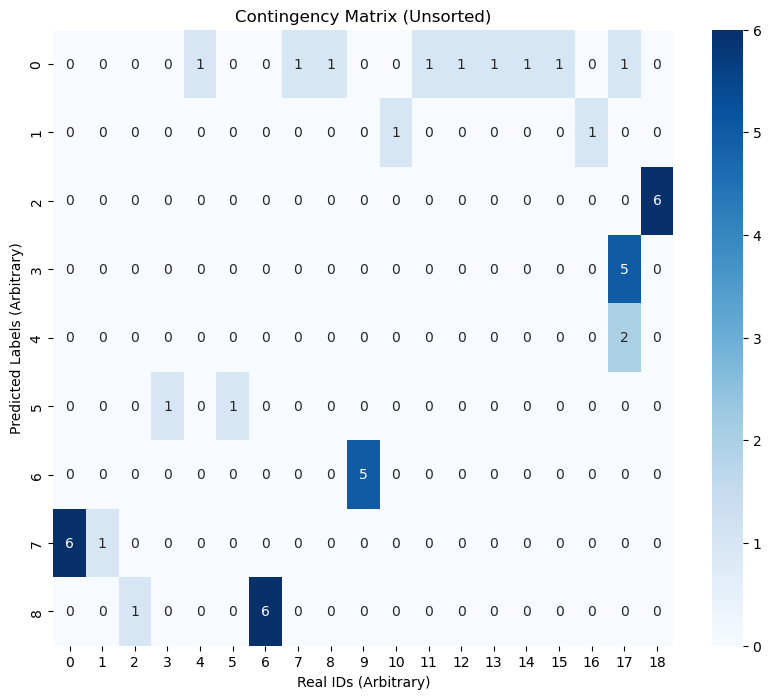

/var/folders/kr/crxb3xqd4wv1ysx_0t4zgxv80000gn/T/ipykernel_63458/783531566.py:241: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['cluster_consensus_insert'] = sub_df.groupby('cluster')['Insert'].transform(get_poa_consensus)


In [138]:
# ==== PARAMS =====

verbose = 3
percentile_th = 5

# ==== RUN =====

barcode_counts = df['Barcode'].value_counts()
all_barcodes = np.array(barcode_counts.index.tolist())

for i, (top_bc, count) in enumerate(barcode_counts.head(1).items()):

    if verbose >= 1:
        print(f"Processing Top Barcode #{i+1}: {top_bc} (Count: {count})")

    # top_bc = "TATCATGGCAGC" # Force specific barcode if needed for debug
    
    # RapidFuzz
    scores = process.cdist([top_bc], all_barcodes, scorer=fuzz.ratio, dtype=np.uint8)[0]
    candidate_bcs = all_barcodes[np.where(scores > 85)[0]]
    filtered_df = df[df['Barcode'].isin(candidate_bcs)].copy()

    if filtered_df.empty: continue

    if verbose >= 2:
        print(f"  > RapidFuzz gathered {len(filtered_df)} reads")

    result_df = iterative_hamming_driver(filtered_df, df, top_bc, 
                                          percentile_th=percentile_th, verbose=verbose)



In [139]:
result_df

,ID,Barcode,Insert,cluster,cluster_consensus_bc,cluster_consensus_insert
612,92,TTTTTATCGT,TGTTAAGGTCTGCACAAGCCTGAGTGCAGGAGTACCGGAG,6,TTTTTATCGT,ATGTTAAGGTCTGCACAAGCCTGAGTGCAGAAGTACCGGACTTAAT...
613,92,TTTTTATCGT,GTGTTAAGGTTCTGCACAAGCCTGAGATGCAAGAAGTACCCGGA,6,TTTTTATCGT,ATGTTAAGGTCTGCACAAGCCTGAGTGCAGAAGTACCGGACTTAAT...
614,92,TTTTTATCGT,ATGTTAAGGGTCTGCACAAGCCTGAGTGCAGAAGTACCGA,6,TTTTTATCGT,ATGTTAAGGTCTGCACAAGCCTGAGTGCAGAAGTACCGGACTTAAT...
616,92,TTTTTATCGT,ATGTTAAGGTCTGACAGCCTGAGTGCAGAAGTACCGA,6,TTTTTATCGT,ATGTTAAGGTCTGCACAAGCCTGAGTGCAGAAGTACCGGACTTAAT...
618,92,TTTTTATCGT,ATGTTAAGGTCTGCACAAGCCTGAGTGCAAGAAGTACCGGA,6,TTTTTATCGT,ATGTTAAGGTCTGCACAAGCCTGAGTGCAGAAGTACCGGACTTAAT...
619,92,TTTTTATCGT,ATGTTAAGGTGTGCACGAGCCTGACGCATGAAGTAACCGGA,6,TTTTTATCGT,ATGTTAAGGTCTGCACAAGCCTGAGTGCAGAAGTACCGGACTTAAT...
16355,2519,TTTTAGTCGGT,CATAAGTTAGTGGACTTAATTTTTATTAGCCCTCTGGCTT,6,TTTTTATCGT,ATGTTAAGGTCTGCACAAGCCTGAGTGCAGAAGTACCGGACTTAAT...
130859,20092,TTTTTATCGT,GGAGTGGTTCATACATAGTCTCATTCTGTTTTAGACACGCGCCGTA...,2,TTTTTATCGT,GGAGTGGTTCACACATAGTCTCATTCTGTTTTAGACACGCGCCGTA...
130860,20092,TTTTTATCGT,GGAGTGGATCACACATAGTCTGCATTCTGTTTTAGACATCGCGCCG...,2,TTTTTATCGT,GGAGTGGTTCACACATAGTCTCATTCTGTTTTAGACACGCGCCGTA...
130861,20092,TTTTTATCGT,GGAGTGGTTCACACATAGTCTCATTCTGTTTTAGACACGCGGCGTA...,2,TTTTTATCGT,GGAGTGGTTCACACATAGTCTCATTCTGTTTTAGACACGCGCCGTA...
